# Data Preparation Pipeline
## Pneumonia Detection Project — Group 4

This notebook performs the full data preparation pipeline for our pneumonia detection project, which combines two datasets:
- **Chest X-Ray Images (Pneumonia)** — 5,856 JPEG images from Kaggle
- **RSNA Pneumonia Detection Challenge** — 27,901 DICOM images from Kaggle

### Install Dependencies

We install the required AWS libraries:
- `sagemaker` — AWS SageMaker SDK for managing ML workflows
- `pyathena` — Python client for querying data with Amazon Athena
- `awswrangler` — simplifies interaction between Pandas and AWS services
- `boto3` — AWS SDK for Python to interact with S3, IAM, and other services

### Verify Data in S3 Data Lake

Our raw image data is stored in a shared S3 bucket (`pneumonia-data-set-group-4`). This bucket serves as our **data lake** — a centralized repository for all raw project data.

Here we connect to the bucket and verify the folder structure and file counts across our training, test, and validation splits for both NORMAL and PNEUMONIA classes.


### Analyze File Formats

Since our project combines two different datasets, the images come in two formats:
- **DICOM (.dcm)** — medical imaging format from the RSNA dataset
- **JPEG (.jpeg)** — standard image format from the Chest X-Ray dataset

We scan all files in S3 to understand the distribution of file types. This is important because each format requires different preprocessing code to read and convert into arrays for model training.

In [1]:
!pip install "sagemaker<3" pyathena awswrangler  --quiet
!pip install 'boto3>1.17.21'

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multimodal 1.5.0 requires nvidia-ml-py3<8.0,>=7.352.0, which is not installed.
autogluon-timeseries 1.5.0 requires chronos-forecasting<2.4,>=2.2.2, which is not installed.
autogluon-timeseries 1.5.0 requires einops<1,>=0.7, which is not installed.
autogluon-timeseries 1.5.0 requires peft<0.18,>=0.13.0, which is not installed.
skops 0.14.0 requires prettytable>=3.9, which is not installed.
autogluon-multimodal 1.5.0 requires fsspec[http]<=2025.3, but you have fsspec 2026.3.0 which is incompatible.
sagemaker-mlops 1.10.0 requires sagemaker-core>=2.10.0, but you have sagemaker-core 1.0.78 which is incompatible.
sagemaker-serve 1.10.0 requires sagemaker-core>=2.10.0, but you have sagemaker-core 1.0.78 which is incompatible.
sagemaker-studio-analytics-extension 0.3.0 requires sparkmagic==0.22.0, but you have 

In [2]:
import boto3

s3 = boto3.client("s3")
bucket = "pneumonia-data-set-group-4"

# Check what top-level folders exist
response = s3.list_objects_v2(Bucket=bucket, Prefix="raw-images/", Delimiter="/")
print("Top folders:")
for prefix in response.get("CommonPrefixes", []):
    print(f"  {prefix['Prefix']}")

# Count files in each folder
paginator = s3.get_paginator("list_objects_v2")
for split in ["train", "test", "val"]:
    for label in ["NORMAL", "PNEUMONIA"]:
        prefix = f"raw-images/{split}/{label}/"
        count = 0
        for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
            count += len(page.get("Contents", []))
        if count > 0:
            print(f"  {split}/{label}: {count} files")

Top folders:
  raw-images/test/
  raw-images/train/
  raw-images/val/


  train/NORMAL: 17927 files


  train/PNEUMONIA: 9220 files


  test/NORMAL: 2272 files


  test/PNEUMONIA: 1338 files


  val/NORMAL: 2058 files
  val/PNEUMONIA: 944 files


In [3]:
import boto3

s3 = boto3.client("s3")
bucket = "pneumonia-data-set-group-4"
paginator = s3.get_paginator("list_objects_v2")

dcm_count = 0
jpeg_count = 0
other_count = 0

for page in paginator.paginate(Bucket=bucket, Prefix="raw-images/"):
    for obj in page.get("Contents", []):
        key = obj["Key"]
        if key.endswith(".dcm"):
            dcm_count += 1
        elif key.endswith((".jpeg", ".jpg", ".png")):
            jpeg_count += 1
        else:
            other_count += 1

print(f"DICOM (.dcm):  {dcm_count}")
print(f"JPEG (.jpeg):  {jpeg_count}")
print(f"Other:         {other_count}")
print(f"Total:         {dcm_count + jpeg_count + other_count}")

DICOM (.dcm):  27901
JPEG (.jpeg):  5858
Other:         0
Total:         33759


### Step 4: Set Up Athena Tables for Cataloging & Querying

Amazon Athena is a serverless query service that lets us run SQL queries directly on data stored in S3. Instead of looping through S3 files every time we need information, we can query our dataset using standard SQL.

Since Athena cannot query raw image files, we create a **metadata table** — a CSV file where each row represents one image with its S3 path, label (NORMAL/PNEUMONIA), split (train/test/val), source (chest_xray/rsna), and file size.

**What happens in this section:**
1. Connect to Athena using PyAthena with a staging directory for query results
2. Create a new database (`pneumonia_db`) in the AWS Glue Data Catalog
3. Scan all 33,757 images in S3 and build a metadata DataFrame
4. Upload the metadata CSV to S3
5. Create an external Athena table pointing to the CSV
6. Run SQL queries to verify the table and explore class distributions



In [4]:
#Setup Connection

import boto3
import sagemaker
import pandas as pd
from pyathena import connect

sess = sagemaker.Session()
default_bucket = sess.default_bucket()
region = boto3.Session().region_name
bucket = "pneumonia-data-set-group-4"

# Athena staging directory (uses YOUR default bucket for query results)
s3_staging_dir = f"s3://{default_bucket}/athena/staging"

# Connect to Athena
conn = connect(region_name=region, s3_staging_dir=s3_staging_dir)

print(f"Region: {region}")
print(f"Data bucket: {bucket}")
print(f"Staging dir: {s3_staging_dir}")

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


Region: us-east-1
Data bucket: pneumonia-data-set-group-4
Staging dir: s3://sagemaker-us-east-1-929599411455/athena/staging


In [5]:
#Create the database

database_name = "pneumonia_db"

statement = f"CREATE DATABASE IF NOT EXISTS {database_name}"
print(statement)
pd.read_sql(statement, conn)
print("✅ Database created!")

CREATE DATABASE IF NOT EXISTS pneumonia_db


/tmp/ipykernel_788/1516474353.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql(statement, conn)


✅ Database created!


In [6]:
df_databases = pd.read_sql("SHOW DATABASES", conn)
print(df_databases)

if database_name in df_databases.values:
    print(f"\n✅ Database '{database_name}' exists!")
else:
    print(f"\n❌ Database '{database_name}' not found")

/tmp/ipykernel_788/2588296401.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_databases = pd.read_sql("SHOW DATABASES", conn)


            database_name
0                 default
1                  dsoaws
2            pneumonia_db
3  sagemaker_featurestore

✅ Database 'pneumonia_db' exists!


In [7]:
# Build metadata from S3 images
s3 = boto3.client("s3")
paginator = s3.get_paginator("list_objects_v2")
rows = []

for split in ["train", "test", "val"]:
    for label in ["NORMAL", "PNEUMONIA"]:
        prefix = f"raw-images/{split}/{label}/"
        for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
            for obj in page.get("Contents", []):
                key = obj["Key"]
                file_name = key.split("/")[-1]
                file_type = "dcm" if file_name.endswith(".dcm") else "jpeg"
                source = "rsna" if file_type == "dcm" else "chest_xray"

                rows.append({
                    "image_id": file_name.replace(".dcm", "").replace(".jpeg", "").replace(".jpg", ""),
                    "s3_key": key,
                    "file_name": file_name,
                    "split": split,
                    "label": label,
                    "file_type": file_type,
                    "source": source,
                    "file_size": obj["Size"]
                })

df_metadata = pd.DataFrame(rows)
print(f"Total images: {len(df_metadata)}")
df_metadata.head()

Total images: 33759


,image_id,s3_key,file_name,split,label,file_type,source,file_size
0,IM-0115-0001-checkpoint,raw-images/train/NORMAL/.ipynb_checkpoints/IM-...,IM-0115-0001-checkpoint.jpeg,train,NORMAL,jpeg,chest_xray,870784
1,IM-0117-0001-checkpoint,raw-images/train/NORMAL/.ipynb_checkpoints/IM-...,IM-0117-0001-checkpoint.jpeg,train,NORMAL,jpeg,chest_xray,406305
2,0004cfab-14fd-4e49-80ba-63a80b6bddd6,raw-images/train/NORMAL/0004cfab-14fd-4e49-80b...,0004cfab-14fd-4e49-80ba-63a80b6bddd6.dcm,train,NORMAL,dcm,rsna,143048
3,0022995a-45eb-4cfa-9a59-cd15f5196c64,raw-images/train/NORMAL/0022995a-45eb-4cfa-9a5...,0022995a-45eb-4cfa-9a59-cd15f5196c64.dcm,train,NORMAL,dcm,rsna,153116
4,0025d2de-bd78-4d36-9f72-e15a5e22ca82,raw-images/train/NORMAL/0025d2de-bd78-4d36-9f7...,0025d2de-bd78-4d36-9f72-e15a5e22ca82.dcm,train,NORMAL,dcm,rsna,121498


In [8]:
# Remove checkpoint files
df_metadata = df_metadata[~df_metadata["s3_key"].str.contains(".ipynb_checkpoint")]

print(f"Total images after cleanup: {len(df_metadata)}")
df_metadata.head()

Total images after cleanup: 33757


,image_id,s3_key,file_name,split,label,file_type,source,file_size
2,0004cfab-14fd-4e49-80ba-63a80b6bddd6,raw-images/train/NORMAL/0004cfab-14fd-4e49-80b...,0004cfab-14fd-4e49-80ba-63a80b6bddd6.dcm,train,NORMAL,dcm,rsna,143048
3,0022995a-45eb-4cfa-9a59-cd15f5196c64,raw-images/train/NORMAL/0022995a-45eb-4cfa-9a5...,0022995a-45eb-4cfa-9a59-cd15f5196c64.dcm,train,NORMAL,dcm,rsna,153116
4,0025d2de-bd78-4d36-9f72-e15a5e22ca82,raw-images/train/NORMAL/0025d2de-bd78-4d36-9f7...,0025d2de-bd78-4d36-9f72-e15a5e22ca82.dcm,train,NORMAL,dcm,rsna,121498
5,002c591d-df62-4e34-8eda-838c664430a9,raw-images/train/NORMAL/002c591d-df62-4e34-8ed...,002c591d-df62-4e34-8eda-838c664430a9.dcm,train,NORMAL,dcm,rsna,125734
6,00322d4d-1c29-4943-afc9-b6754be640eb,raw-images/train/NORMAL/00322d4d-1c29-4943-afc...,00322d4d-1c29-4943-afc9-b6754be640eb.dcm,train,NORMAL,dcm,rsna,125284


In [9]:
# Save locally then upload
csv_path = "image_metadata.csv"
df_metadata.to_csv(csv_path, index=False)

# Upload to YOUR default bucket (you have write access)
s3.upload_file(csv_path, default_bucket, "pneumonia-project/metadata/image_metadata.csv")
print(f"✅ Metadata uploaded to s3://{default_bucket}/pneumonia-project/metadata/image_metadata.csv")

✅ Metadata uploaded to s3://sagemaker-us-east-1-929599411455/pneumonia-project/metadata/image_metadata.csv


In [10]:
statement = f"""
CREATE EXTERNAL TABLE IF NOT EXISTS {database_name}.image_metadata (
    image_id     STRING,
    s3_key       STRING,
    file_name    STRING,
    split        STRING,
    label        STRING,
    file_type    STRING,
    source       STRING,
    file_size    BIGINT
)
ROW FORMAT DELIMITED
FIELDS TERMINATED BY ','
LOCATION 's3://{default_bucket}/pneumonia-project/metadata/'
TBLPROPERTIES ('skip.header.line.count'='1')
"""

print(statement)
pd.read_sql(statement, conn)
print("✅ Table created!")


CREATE EXTERNAL TABLE IF NOT EXISTS pneumonia_db.image_metadata (
    image_id     STRING,
    s3_key       STRING,
    file_name    STRING,
    split        STRING,
    label        STRING,
    file_type    STRING,
    source       STRING,
    file_size    BIGINT
)
ROW FORMAT DELIMITED
FIELDS TERMINATED BY ','
LOCATION 's3://sagemaker-us-east-1-929599411455/pneumonia-project/metadata/'
TBLPROPERTIES ('skip.header.line.count'='1')



/tmp/ipykernel_788/4014713479.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql(statement, conn)


✅ Table created!


In [11]:
df_tables = pd.read_sql(f"SHOW TABLES IN {database_name}", conn)
print(df_tables)

if "image_metadata" in df_tables.values:
    print("\n✅ Table 'image_metadata' exists!")
else:
    print("\n❌ Table not found")

/tmp/ipykernel_788/1759804955.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_tables = pd.read_sql(f"SHOW TABLES IN {database_name}", conn)


         tab_name
0  image_metadata

✅ Table 'image_metadata' exists!


In [12]:
# Query 1 - Count all images
df_count = pd.read_sql(f"""
    SELECT COUNT(*) as total_images 
    FROM {database_name}.image_metadata
""", conn)
print("Total images:")
print(df_count)

# Query 2 - Class distribution
df_labels = pd.read_sql(f"""
    SELECT label, COUNT(*) as count 
    FROM {database_name}.image_metadata 
    GROUP BY label
""", conn)
print("\nClass distribution:")
print(df_labels)

# Query 3 - Breakdown by split, label, source
df_breakdown = pd.read_sql(f"""
    SELECT split, label, source, COUNT(*) as count 
    FROM {database_name}.image_metadata 
    GROUP BY split, label, source
    ORDER BY split, label, source
""", conn)
print("\nFull breakdown:")
print(df_breakdown)

/tmp/ipykernel_788/3826437158.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_count = pd.read_sql(f"""


Total images:
   total_images
0         33757


/tmp/ipykernel_788/3826437158.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_labels = pd.read_sql(f"""



Class distribution:
       label  count
0     NORMAL  22255
1  PNEUMONIA  11502


/tmp/ipykernel_788/3826437158.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_breakdown = pd.read_sql(f"""



Full breakdown:
    split      label      source  count
0    test     NORMAL  chest_xray    234
1    test     NORMAL        rsna   2038
2    test  PNEUMONIA  chest_xray    390
3    test  PNEUMONIA        rsna    948
4   train     NORMAL  chest_xray   1341
5   train     NORMAL        rsna  16584
6   train  PNEUMONIA  chest_xray   3875
7   train  PNEUMONIA        rsna   5345
8     val     NORMAL  chest_xray      8
9     val     NORMAL        rsna   2050
10    val  PNEUMONIA  chest_xray      8
11    val  PNEUMONIA        rsna    936


### Step 5: Exploratory Data Analysis (EDA)

In this section, we explore our combined pneumonia dataset to understand its characteristics before building a model. EDA helps us identify potential issues like class imbalance, inconsistent image sizes, and differences between our two data sources (Chest X-Ray and RSNA).

**What we analyze:**
1. **Class distribution** — How balanced are NORMAL vs PNEUMONIA labels across splits and sources?
2. **Sample images** — Visual comparison of Normal vs Pneumonia X-rays from both datasets
3. **Image dimensions** — Are image sizes consistent? Do they need resizing?
4. **Pixel intensity** — Are there brightness/contrast differences between classes or sources?

These insights will guide our preprocessing and feature engineering decisions in the next steps.

In [13]:
!pip install pydicom opencv-python-headless matplotlib seaborn --quiet

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multimodal 1.5.0 requires nvidia-ml-py3<8.0,>=7.352.0, which is not installed.
autogluon-timeseries 1.5.0 requires chronos-forecasting<2.4,>=2.2.2, which is not installed.
autogluon-timeseries 1.5.0 requires einops<1,>=0.7, which is not installed.
autogluon-timeseries 1.5.0 requires peft<0.18,>=0.13.0, which is not installed.
skops 0.14.0 requires prettytable>=3.9, which is not installed.
amazon-sagemaker-sql-magic 0.1.4 requires numpy<2, but you have numpy 2.4.6 which is incompatible.
autogluon-common 1.5.0 requires numpy<2.4.0,>=1.25.0, but you have numpy 2.4.6 which is incompatible.
autogluon-common 1.5.0 requires pyarrow<21.0.0,>=7.0.0, but you have pyarrow 21.0.0 which is incompatible.
autogluon-core 1.5.0 requires numpy<2.4.0,>=1.25.0, but you have numpy 2.4.6 which is incompatible.
autogluon-featu

In [14]:
import boto3
import numpy as np
import cv2
import pydicom
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import io
import random

s3 = boto3.client("s3")
bucket = "pneumonia-data-set-group-4"

print("✅ Setup complete")

✅ Setup complete


In [15]:
# Build metadata from S3 
paginator = s3.get_paginator("list_objects_v2")
rows = []

for split in ["train", "test", "val"]:
    for label in ["NORMAL", "PNEUMONIA"]:
        prefix = f"raw-images/{split}/{label}/"
        for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
            for obj in page.get("Contents", []):
                key = obj["Key"]
                if ".ipynb_checkpoint" in key:
                    continue  # skip junk files
                file_name = key.split("/")[-1]
                file_type = "dcm" if file_name.endswith(".dcm") else "jpeg"
                source = "rsna" if file_type == "dcm" else "chest_xray"

                rows.append({
                    "image_id": file_name.replace(".dcm", "").replace(".jpeg", "").replace(".jpg", ""),
                    "s3_key": key,
                    "file_name": file_name,
                    "split": split,
                    "label": label,
                    "file_type": file_type,
                    "source": source,
                    "file_size": obj["Size"]
                })

df = pd.DataFrame(rows)
print(f"Total images: {len(df)}")
df.head()

Total images: 33757


,image_id,s3_key,file_name,split,label,file_type,source,file_size
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,raw-images/train/NORMAL/0004cfab-14fd-4e49-80b...,0004cfab-14fd-4e49-80ba-63a80b6bddd6.dcm,train,NORMAL,dcm,rsna,143048
1,0022995a-45eb-4cfa-9a59-cd15f5196c64,raw-images/train/NORMAL/0022995a-45eb-4cfa-9a5...,0022995a-45eb-4cfa-9a59-cd15f5196c64.dcm,train,NORMAL,dcm,rsna,153116
2,0025d2de-bd78-4d36-9f72-e15a5e22ca82,raw-images/train/NORMAL/0025d2de-bd78-4d36-9f7...,0025d2de-bd78-4d36-9f72-e15a5e22ca82.dcm,train,NORMAL,dcm,rsna,121498
3,002c591d-df62-4e34-8eda-838c664430a9,raw-images/train/NORMAL/002c591d-df62-4e34-8ed...,002c591d-df62-4e34-8eda-838c664430a9.dcm,train,NORMAL,dcm,rsna,125734
4,00322d4d-1c29-4943-afc9-b6754be640eb,raw-images/train/NORMAL/00322d4d-1c29-4943-afc...,00322d4d-1c29-4943-afc9-b6754be640eb.dcm,train,NORMAL,dcm,rsna,125284


In [16]:
#Dataset overview

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)

print(f"\nTotal images: {len(df)}")

print(f"\nBy label:")
print(df["label"].value_counts())

print(f"\nBy split:")
print(df["split"].value_counts())

print(f"\nBy source:")
print(df["source"].value_counts())

normal = len(df[df["label"] == "NORMAL"])
pneumonia = len(df[df["label"] == "PNEUMONIA"])
print(f"\nClass ratio - Normal:Pneumonia = {normal/pneumonia:.2f}:1")

DATASET OVERVIEW

Total images: 33757

By label:
label
NORMAL       22255
PNEUMONIA    11502
Name: count, dtype: int64

By split:
split
train    27145
test      3610
val       3002
Name: count, dtype: int64

By source:
source
rsna          27901
chest_xray     5856
Name: count, dtype: int64

Class ratio - Normal:Pneumonia = 1.93:1


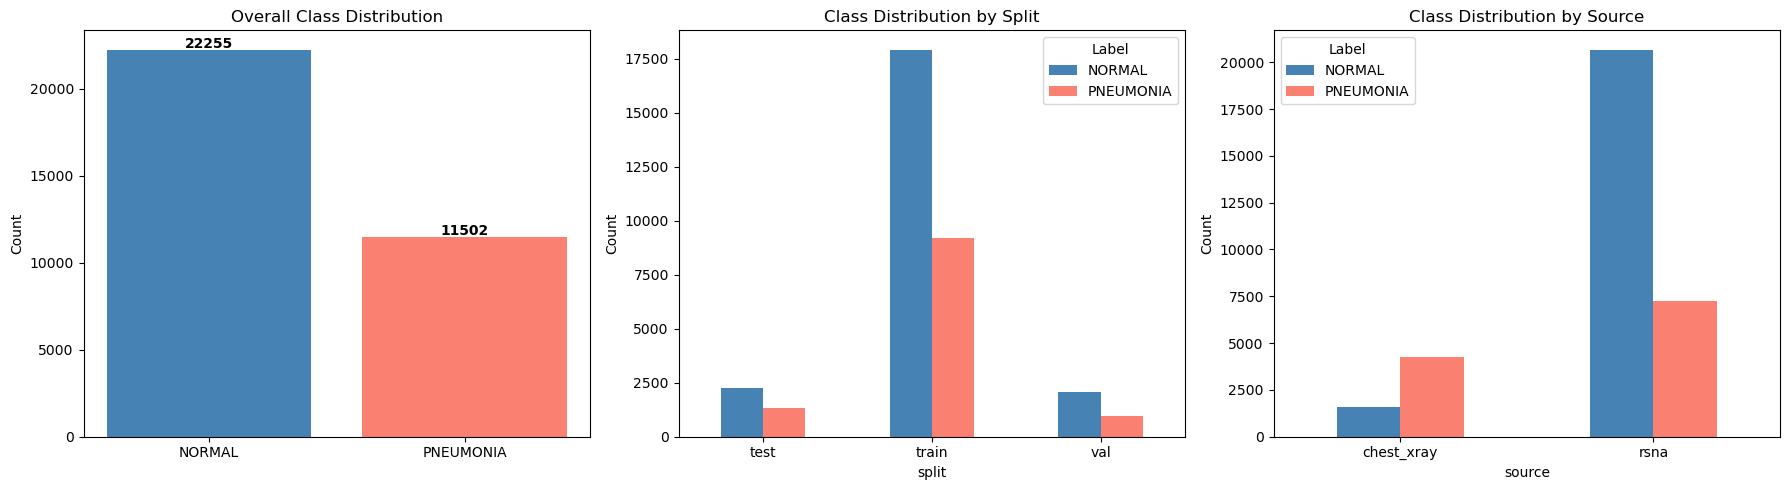

In [17]:
#Class distribution charts

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Overall class balance
counts = df["label"].value_counts()
axes[0].bar(counts.index, counts.values, color=["steelblue", "salmon"])
axes[0].set_title("Overall Class Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, str(v), ha="center", fontweight="bold")

# By split
split_counts = df.groupby(["split", "label"]).size().unstack(fill_value=0)
split_counts.plot(kind="bar", ax=axes[1], color=["steelblue", "salmon"])
axes[1].set_title("Class Distribution by Split")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Label")

# By source
source_counts = df.groupby(["source", "label"]).size().unstack(fill_value=0)
source_counts.plot(kind="bar", ax=axes[2], color=["steelblue", "salmon"])
axes[2].set_title("Class Distribution by Source")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis="x", rotation=0)
axes[2].legend(title="Label")

plt.tight_layout()
plt.show()

In [18]:
#helper function to load images from S3

def load_image_from_s3(s3_key):
    """Load an image from S3 - handles both JPEG and DICOM formats"""
    response = s3.get_object(Bucket=bucket, Key=s3_key)
    img_bytes = response["Body"].read()

    if s3_key.endswith(".dcm"):
        # DICOM format (RSNA dataset)
        ds = pydicom.dcmread(io.BytesIO(img_bytes))
        img = ds.pixel_array
        img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    else:
        # JPEG format (Chest X-Ray dataset)
        img_array = np.frombuffer(img_bytes, np.uint8)
        img = cv2.imdecode(img_array, cv2.IMREAD_GRAYSCALE)

    return img

# Test it
test_key = df.iloc[0]["s3_key"]
test_img = load_image_from_s3(test_key)
print(f"✅ Loaded image — shape: {test_img.shape}, dtype: {test_img.dtype}")

✅ Loaded image — shape: (1024, 1024), dtype: uint8


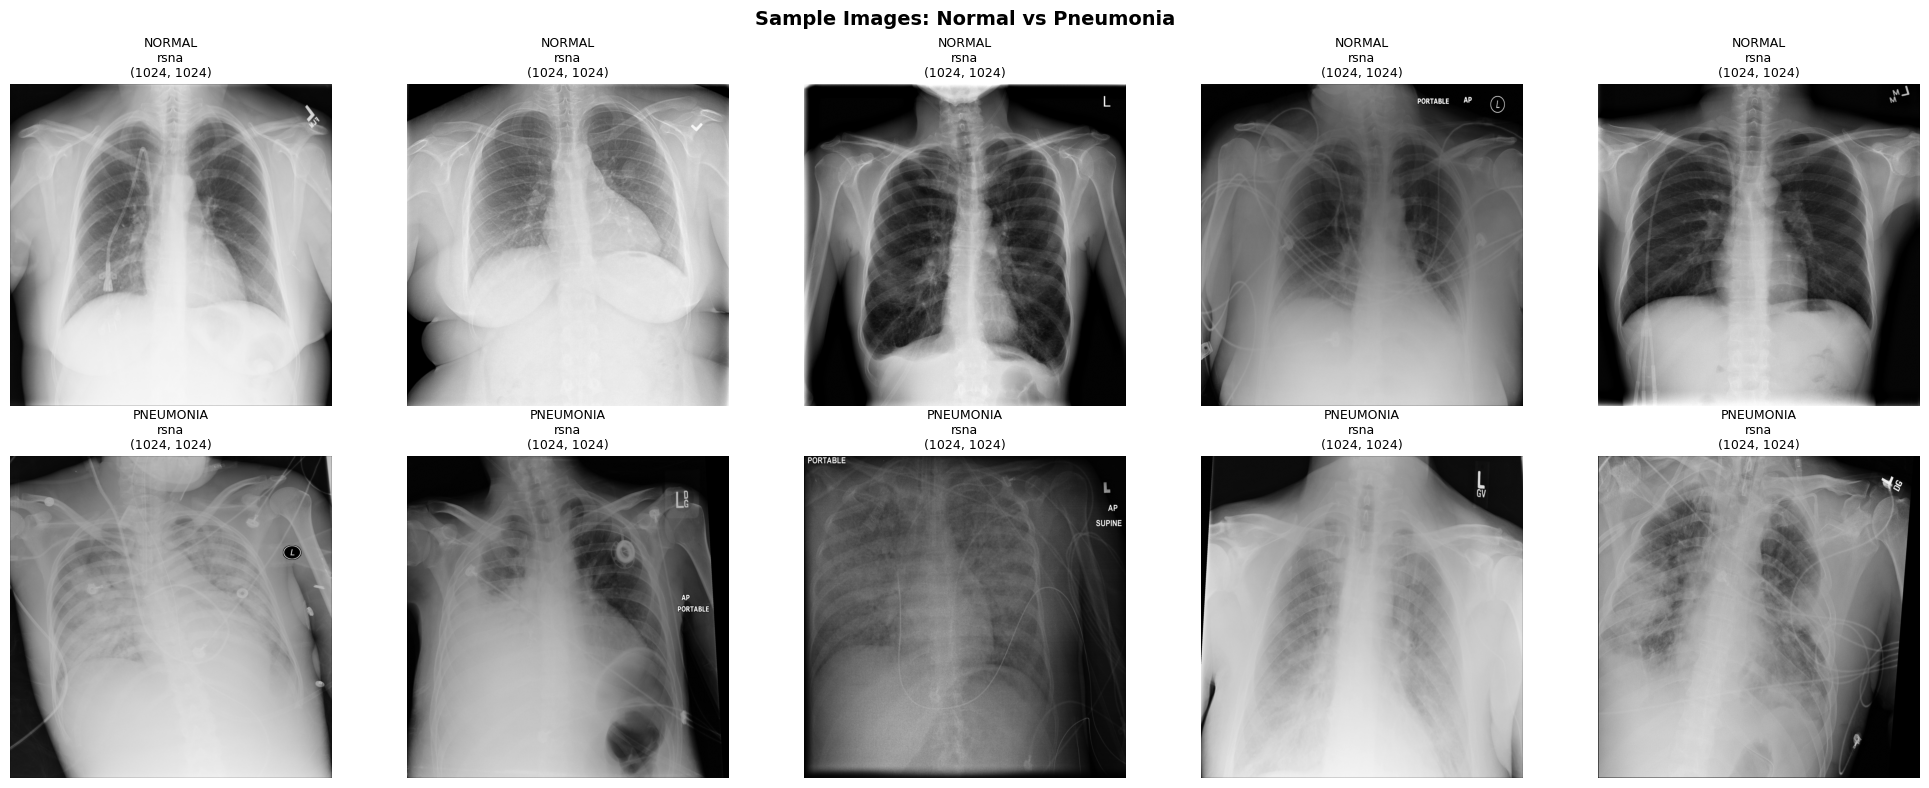

In [19]:
#Visualize sample images:

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

normal_samples = df[df["label"] == "NORMAL"].sample(5, random_state=42)
pneumonia_samples = df[df["label"] == "PNEUMONIA"].sample(5, random_state=42)

# Normal images (top row)
for i, (_, row) in enumerate(normal_samples.iterrows()):
    img = load_image_from_s3(row["s3_key"])
    axes[0][i].imshow(img, cmap="gray")
    axes[0][i].set_title(f"NORMAL\n{row['source']}\n{img.shape}", fontsize=9)
    axes[0][i].axis("off")

# Pneumonia images (bottom row)
for i, (_, row) in enumerate(pneumonia_samples.iterrows()):
    img = load_image_from_s3(row["s3_key"])
    axes[1][i].imshow(img, cmap="gray")
    axes[1][i].set_title(f"PNEUMONIA\n{row['source']}\n{img.shape}", fontsize=9)
    axes[1][i].axis("off")

plt.suptitle("Sample Images: Normal vs Pneumonia", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Analyzing image sizes 


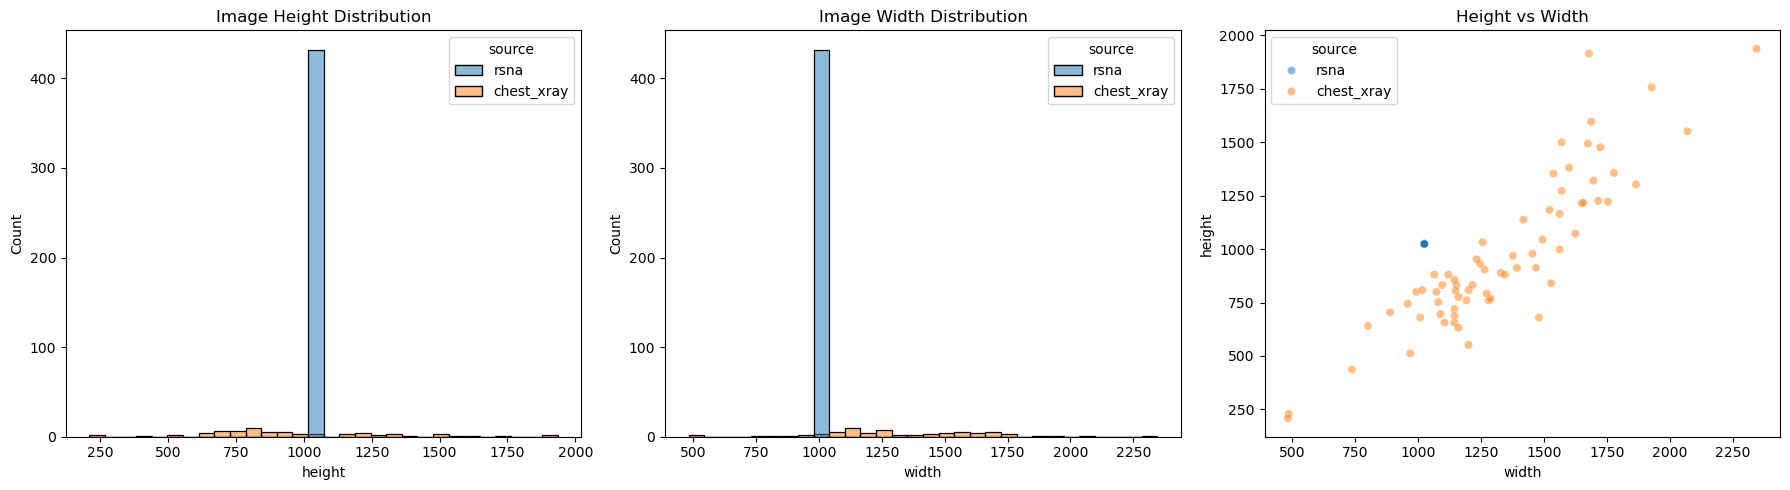


Image size stats:
           height                                                           \
            count         mean         std     min     25%     50%     75%   
source                                                                       
chest_xray   68.0   971.323529  353.746154   209.0   758.0   880.0  1214.5   
rsna        432.0  1024.000000    0.000000  1024.0  1024.0  1024.0  1024.0   

                    width                                                   \
               max  count         mean         std     min     25%     50%   
source                                                                       
chest_xray  1936.0   68.0  1336.058824  341.896462   482.0  1138.0  1276.0   
rsna        1024.0  432.0  1024.000000    0.000000  1024.0  1024.0  1024.0   

                            
               75%     max  
source                      
chest_xray  1570.0  2345.0  
rsna        1024.0  1024.0  


In [20]:
#Image size distribution
# Sample 500 images to check sizes

sample_df = df.sample(min(500, len(df)), random_state=42)

heights, widths, sources, labels = [], [], [], []

print("Analyzing image sizes ")
for _, row in sample_df.iterrows():
    try:
        img = load_image_from_s3(row["s3_key"])
        heights.append(img.shape[0])
        widths.append(img.shape[1])
        sources.append(row["source"])
        labels.append(row["label"])
    except:
        continue

size_df = pd.DataFrame({"height": heights, "width": widths, "source": sources, "label": labels})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=size_df, x="height", hue="source", ax=axes[0], bins=30)
axes[0].set_title("Image Height Distribution")

sns.histplot(data=size_df, x="width", hue="source", ax=axes[1], bins=30)
axes[1].set_title("Image Width Distribution")

sns.scatterplot(data=size_df, x="width", y="height", hue="source", alpha=0.5, ax=axes[2])
axes[2].set_title("Height vs Width")

plt.tight_layout()
plt.show()

print("\nImage size stats:")
print(size_df.groupby("source")[["height", "width"]].describe())

Analyzing pixel intensities...


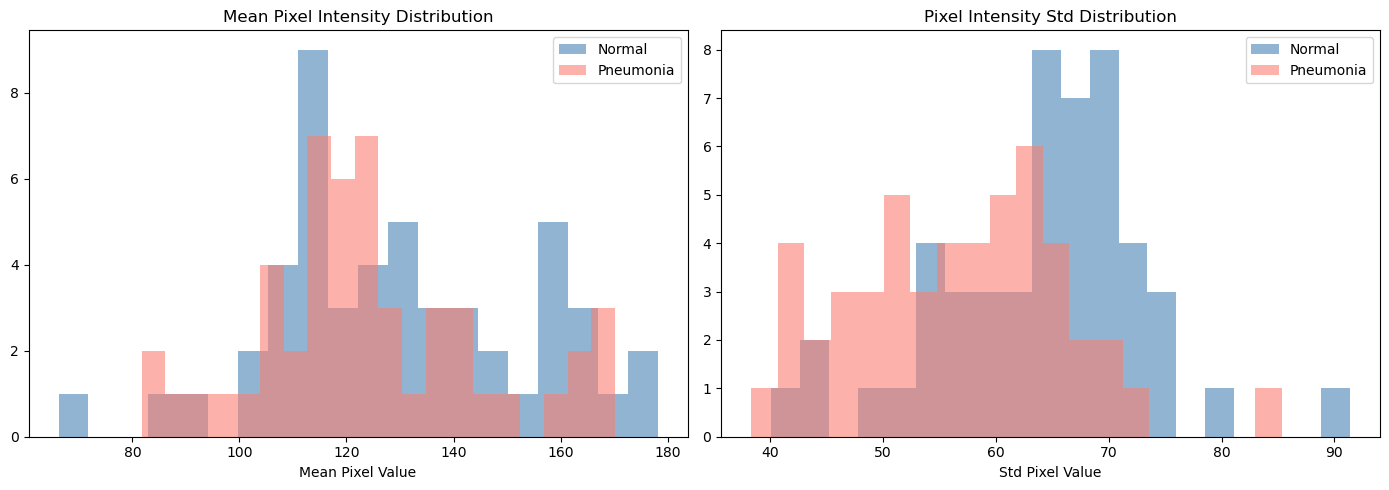

Normal    — Mean: 129.7, Std: 64.2
Pneumonia — Mean: 124.5, Std: 56.6


In [21]:
#Pixel intensity analysis

sample_normal = df[df["label"] == "NORMAL"].sample(50, random_state=42)
sample_pneumonia = df[df["label"] == "PNEUMONIA"].sample(50, random_state=42)

normal_means, pneumonia_means = [], []
normal_stds, pneumonia_stds = [], []

print("Analyzing pixel intensities...")

for _, row in sample_normal.iterrows():
    try:
        img = load_image_from_s3(row["s3_key"])
        normal_means.append(img.mean())
        normal_stds.append(img.std())
    except:
        continue

for _, row in sample_pneumonia.iterrows():
    try:
        img = load_image_from_s3(row["s3_key"])
        pneumonia_means.append(img.mean())
        pneumonia_stds.append(img.std())
    except:
        continue

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(normal_means, bins=20, alpha=0.6, label="Normal", color="steelblue")
axes[0].hist(pneumonia_means, bins=20, alpha=0.6, label="Pneumonia", color="salmon")
axes[0].set_title("Mean Pixel Intensity Distribution")
axes[0].set_xlabel("Mean Pixel Value")
axes[0].legend()

axes[1].hist(normal_stds, bins=20, alpha=0.6, label="Normal", color="steelblue")
axes[1].hist(pneumonia_stds, bins=20, alpha=0.6, label="Pneumonia", color="salmon")
axes[1].set_title("Pixel Intensity Std Distribution")
axes[1].set_xlabel("Std Pixel Value")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Normal    — Mean: {np.mean(normal_means):.1f}, Std: {np.mean(normal_stds):.1f}")
print(f"Pneumonia — Mean: {np.mean(pneumonia_means):.1f}, Std: {np.mean(pneumonia_stds):.1f}")

In [22]:
print("=" * 50)
print("EDA SUMMARY")
print("=" * 50)
print(f"""
Total Images:     {len(df)}
  - Normal:       {len(df[df['label']=='NORMAL'])} ({len(df[df['label']=='NORMAL'])/len(df)*100:.1f}%)
  - Pneumonia:    {len(df[df['label']=='PNEUMONIA'])} ({len(df[df['label']=='PNEUMONIA'])/len(df)*100:.1f}%)

Sources:
  - Chest X-Ray:  {len(df[df['source']=='chest_xray'])} JPEG images
  - RSNA:         {len(df[df['source']=='rsna'])} DICOM images

Splits:
  - Train:        {len(df[df['split']=='train'])}
  - Test:         {len(df[df['split']=='test'])}
  - Val:          {len(df[df['split']=='val'])}

Key Findings:
  1. Class imbalance: {len(df[df['label']=='NORMAL'])/len(df[df['label']=='PNEUMONIA']):.2f}:1 ratio (Normal:Pneumonia)
  2. Two file formats need unified preprocessing (DICOM + JPEG)
  3. Image sizes vary — need resizing to 512x512 (per config.py)
""")

EDA SUMMARY

Total Images:     33757
  - Normal:       22255 (65.9%)
  - Pneumonia:    11502 (34.1%)

Sources:
  - Chest X-Ray:  5856 JPEG images
  - RSNA:         27901 DICOM images

Splits:
  - Train:        27145
  - Test:         3610
  - Val:          3002

Key Findings:
  1. Class imbalance: 1.93:1 ratio (Normal:Pneumonia)
  2. Two file formats need unified preprocessing (DICOM + JPEG)
  3. Image sizes vary — need resizing to 512x512 (per config.py)



### Step 6: Feature Engineering & SageMaker Feature Store

In this section, we preprocess our raw X-ray images to make them ready for CNN model training, and store a **training manifest** in Amazon SageMaker Feature Store.

**Image Preprocessing Pipeline:**
1. Read image from S3 (handles both DICOM and JPEG formats)
2. Normalize pixel values to 0-255 (uint8)
3. Apply CLAHE contrast enhancement (improves X-ray detail visibility)
4. Resize to 512×512 (uniform size for CNN input)
5. Save preprocessed image back to S3

**Feature Store Manifest:**

Since we are using a CNN for classification, the model learns its own features directly from the images — we don't need handcrafted features like edge density or skewness. Instead, we store a **training manifest** in the Feature Store — a queryable lookup table that maps each image to its preprocessed S3 path, label, and normalization statistics.

This allows the training pipeline to query the Feature Store and immediately know:
- Where each preprocessed image lives in S3
- What label it has (0 = Normal, 1 = Pneumonia)
- Which split it belongs to (train/test/val/production)
- The pixel mean and std for normalization during training

This eliminates the need to scan S3 folders and guess labels from directory names every time we train.

In [23]:
!pip install pydicom opencv-python-headless --quiet

In [32]:
# Setup

import boto3
import sagemaker
import pandas as pd
import numpy as np
import cv2
import pydicom
import io
import time
import tempfile
import os
from datetime import datetime
from sagemaker.feature_store.feature_group import FeatureGroup

sess = sagemaker.Session()
role = sagemaker.get_execution_role()
region = boto3.Session().region_name
default_bucket = sess.default_bucket()
s3 = boto3.client("s3")
bucket = "pneumonia-data-set-group-4"

print(f"Role: {role}")
print(f"Region: {region}")
print(f"Default bucket: {default_bucket}")

Role: arn:aws:iam::929599411455:role/LabRole
Region: us-east-1
Default bucket: sagemaker-us-east-1-929599411455


In [28]:
# helper functions to load images from S3 and preprocess them for CNN training

IMG_SIZE = (512, 512)

def load_image_from_s3(s3_key):
    """Load image from S3 - handles both JPEG and DICOM"""
    response = s3.get_object(Bucket=bucket, Key=s3_key)
    img_bytes = response["Body"].read()

    if s3_key.endswith(".dcm"):
        ds = pydicom.dcmread(io.BytesIO(img_bytes))
        img = ds.pixel_array
    else:
        img_array = np.frombuffer(img_bytes, np.uint8)
        img = cv2.imdecode(img_array, cv2.IMREAD_GRAYSCALE)

    return img


def preprocess_image(img):
    img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)

    img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_LINEAR)

    return img


# Test it
test_key = "raw-images/train/NORMAL/0004cfab-14fd-4e49-80ba-63a80b6bddd6.dcm"
test_img = load_image_from_s3(test_key)
processed = preprocess_image(test_img)
print(f"Raw: {test_img.shape} → Preprocessed: {processed.shape}")

Raw: (1024, 1024) → Preprocessed: (512, 512)


In [29]:
#Get metadata from Athena

import awswrangler as wr

df_meta = wr.athena.read_sql_query(
    "SELECT * FROM pneumonia_db.image_metadata",
    database="pneumonia_db"
)

# Remove checkpoint files if any
df_meta = df_meta[~df_meta["s3_key"].str.contains(".ipynb_checkpoint")]

print(f"Total images to process: {len(df_meta)}")

Total images to process: 33757


In [40]:
#Preprocess images and save to S3
# 500 is only for testing purpose
# Change to len(df_meta) for full dataset while ready for training

SAMPLE_SIZE = 1000 

sample = df_meta.sample(SAMPLE_SIZE, random_state=42)
manifest_rows = []
errors = 0

print(f"Preprocessing {SAMPLE_SIZE} images...")

for i, (_, row) in enumerate(sample.iterrows()):
    try:
        # Load raw image
        img = load_image_from_s3(row["s3_key"])

        # Preprocess
        processed = preprocess_image(img)

        # Calculate pixel stats (for normalization during training)
        pixel_mean = float(np.mean(processed))
        pixel_std = float(np.std(processed))

        # Save preprocessed image to S3
        preprocessed_key = f"preprocessed-images/{row['split']}/{row['label']}/{row['image_id']}.png"
        _, buf = cv2.imencode(".png", processed)
        s3.put_object(
            Bucket=default_bucket,
            Key=preprocessed_key,
            Body=buf.tobytes()
        )

        # Build manifest row
        manifest_rows.append({
            "image_id": str(row["image_id"]),
            "raw_s3_key": str(row["s3_key"]),
            "preprocessed_s3_key": f"s3://{default_bucket}/{preprocessed_key}",
            "label": str(row["label"]),
            "label_int": int(1 if row["label"] == "PNEUMONIA" else 0),
            "split": str(row["split"]),
            "source": str(row["source"]),
            "file_type": str(row["file_type"]),
            "pixel_mean": round(pixel_mean, 4),
            "pixel_std": round(pixel_std, 4),
            "img_height": 512,
            "img_width": 512,
            "event_time": datetime.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ")
        })

    except Exception as e:
        print(e)
        errors += 1
        continue

    if (i + 1) % 100 == 0:
        print(f"  Processed {i + 1}/{SAMPLE_SIZE}...")

df_manifest = pd.DataFrame(manifest_rows)
print(f"\n✅ Done! Preprocessed {len(df_manifest)} images ({errors} errors)")
df_manifest.head()

Preprocessing 1000 images...


/tmp/ipykernel_788/93620534.py:48: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "event_time": datetime.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ")


  Processed 100/1000...


  Processed 200/1000...


  Processed 300/1000...


...

  Processed 700/1000...


  Processed 800/1000...


  Processed 900/1000...


  Processed 1000/1000...

✅ Done! Preprocessed 1000 images (0 errors)


,image_id,raw_s3_key,preprocessed_s3_key,label,label_int,split,source,file_type,pixel_mean,pixel_std,img_height,img_width,event_time
0,90e0bb9c-20a2-4a20-ab79-57ad5c2386aa,raw-images/test/NORMAL/90e0bb9c-20a2-4a20-ab79...,s3://sagemaker-us-east-1-929599411455/preproce...,NORMAL,0,test,rsna,dcm,136.4194,67.8537,512,512,2026-06-02T02:56:50Z
1,53e19ad2-b78a-489b-a7af-45b11462f734,raw-images/train/NORMAL/53e19ad2-b78a-489b-a7a...,s3://sagemaker-us-east-1-929599411455/preproce...,NORMAL,0,train,rsna,dcm,118.3275,73.4934,512,512,2026-06-02T02:56:50Z
2,e065606f-3368-47ff-b4d1-ef783e97813f,raw-images/test/PNEUMONIA/e065606f-3368-47ff-b...,s3://sagemaker-us-east-1-929599411455/preproce...,PNEUMONIA,1,test,rsna,dcm,121.4350,64.0833,512,512,2026-06-02T02:56:50Z
3,342868be-14cd-4700-82c6-575f62097e6e,raw-images/train/PNEUMONIA/342868be-14cd-4700-...,s3://sagemaker-us-east-1-929599411455/preproce...,PNEUMONIA,1,train,rsna,dcm,119.2195,65.5791,512,512,2026-06-02T02:56:50Z
4,5db2fbb6-4da5-47ce-a4dd-94cf2d956d4d,raw-images/train/NORMAL/5db2fbb6-4da5-47ce-a4d...,s3://sagemaker-us-east-1-929599411455/preproce...,NORMAL,0,train,rsna,dcm,157.9597,64.5228,512,512,2026-06-02T02:56:50Z


In [41]:
 #Fix data types for Feature Store

df_manifest["image_id"] = df_manifest["image_id"].astype(str)
df_manifest["raw_s3_key"] = df_manifest["raw_s3_key"].astype(str)
df_manifest["preprocessed_s3_key"] = df_manifest["preprocessed_s3_key"].astype(str)
df_manifest["label"] = df_manifest["label"].astype(str)
df_manifest["split"] = df_manifest["split"].astype(str)
df_manifest["source"] = df_manifest["source"].astype(str)
df_manifest["file_type"] = df_manifest["file_type"].astype(str)
df_manifest["event_time"] = df_manifest["event_time"].astype(str)

df_manifest["label_int"] = df_manifest["label_int"].astype(int)
df_manifest["img_height"] = df_manifest["img_height"].astype(int)
df_manifest["img_width"] = df_manifest["img_width"].astype(int)
df_manifest["pixel_mean"] = df_manifest["pixel_mean"].astype(float)
df_manifest["pixel_std"] = df_manifest["pixel_std"].astype(float)

print("✅ Data types ready")
print(df_manifest.dtypes)

✅ Data types ready
image_id                object
raw_s3_key              object
preprocessed_s3_key     object
label                   object
label_int                int64
split                   object
source                  object
file_type               object
pixel_mean             float64
pixel_std              float64
img_height               int64
img_width                int64
event_time              object
dtype: object


In [42]:
#Create Feature Group

feature_group_name = "pneumonia-training-manifest"

feature_group = FeatureGroup(
    name=feature_group_name,
    sagemaker_session=sess
)

feature_group.load_feature_definitions(data_frame=df_manifest)

print(f"Feature group: {feature_group_name}")
print(f"Columns:")
for feat_def in feature_group.feature_definitions:
    print(f"  {feat_def.feature_name}: {feat_def.feature_type}")

Feature group: pneumonia-training-manifest
Columns:
  image_id: FeatureTypeEnum.STRING
  raw_s3_key: FeatureTypeEnum.STRING
  preprocessed_s3_key: FeatureTypeEnum.STRING
  label: FeatureTypeEnum.STRING
  label_int: FeatureTypeEnum.INTEGRAL
  split: FeatureTypeEnum.STRING
  source: FeatureTypeEnum.STRING
  file_type: FeatureTypeEnum.STRING
  pixel_mean: FeatureTypeEnum.FRACTIONAL
  pixel_std: FeatureTypeEnum.FRACTIONAL
  img_height: FeatureTypeEnum.INTEGRAL
  img_width: FeatureTypeEnum.INTEGRAL
  event_time: FeatureTypeEnum.STRING


In [47]:
#Create Feature Group in Feature Store

try:
    feature_group.create(
        s3_uri=f"s3://{default_bucket}/feature-store/",
        record_identifier_name="image_id",
        event_time_feature_name="event_time",
        role_arn=role,
        enable_online_store=True
    )
    print("Creating feature group (this may take a minute)...")
    
    status = feature_group.describe().get("FeatureGroupStatus")
    while status == "Creating":
        print(f"  Status: {status}...")
        time.sleep(5)
        status = feature_group.describe().get("FeatureGroupStatus")
except Exception as e:
    print(f'error code: {e.response["Error"]["Code"]}')
    if e.response["Error"]["Code"] == "ResourceInUse" and "Resource Already Exists" in str(e):
        print("Group already exists. Continuing...")



print(f"✅ Feature group status: {status}")

error code: ResourceInUse
Group already exists. Continuing...
✅ Feature group status: Created


In [48]:
print(f"Ingesting {len(df_manifest)} records into Feature Store...")

feature_group.ingest(
    data_frame=df_manifest,
    max_workers=3,
    wait=True
)

print("✅ Feature ingestion complete!")

Ingesting 1000 records into Feature Store...


✅ Feature ingestion complete!


In [49]:
## Check the actual table name and database that Feature Store created 
import time

# Wait longer for offline store to sync
print("Waiting 120 seconds for offline store to sync...")
time.sleep(120)

# Check the actual table name in the Glue catalog
feature_store_query = feature_group.athena_query()

# Print the table name Feature Store is using
print(f"Table name: {feature_store_query.table_name}")
print(f"Database: {feature_store_query.database}")
print(f"Catalog: {feature_store_query.catalog}")

Waiting 120 seconds for offline store to sync...


Table name: pneumonia_training_manifest_1780368800
Database: sagemaker_featurestore
Catalog: AwsDataCatalog


In [51]:
# Query the Feature Store offline store to verify the ingested data
feature_store_query.run(
    query_string=f'SELECT label, COUNT(*) as count FROM "pneumonia_training_manifest_1780368800" GROUP BY label',
    output_location=f"s3://{default_bucket}/feature-store/query_results/"
)

feature_store_query.wait()
df_result = feature_store_query.as_dataframe()
print("Feature Store contents:")
print(df_result)

Feature Store contents:
       label  count
0  PNEUMONIA    167
1     NORMAL    333


In [52]:
# Test retrieving a single record from the Feature Store online store
featurestore_runtime = boto3.client("sagemaker-featurestore-runtime", region_name=region)

sample_id = df_manifest["image_id"].iloc[0]

response = featurestore_runtime.get_record(
    FeatureGroupName=feature_group_name,
    RecordIdentifierValueAsString=sample_id
)

print(f"Record for image: {sample_id}")
for feature in response["Record"]:
    print(f"  {feature['FeatureName']}: {feature['ValueAsString']}")

Record for image: 90e0bb9c-20a2-4a20-ab79-57ad5c2386aa
  image_id: 90e0bb9c-20a2-4a20-ab79-57ad5c2386aa
  raw_s3_key: raw-images/test/NORMAL/90e0bb9c-20a2-4a20-ab79-57ad5c2386aa.dcm
  preprocessed_s3_key: s3://sagemaker-us-east-1-929599411455/preprocessed-images/test/NORMAL/90e0bb9c-20a2-4a20-ab79-57ad5c2386aa.png
  label: NORMAL
  label_int: 0
  split: test
  source: rsna
  file_type: dcm
  pixel_mean: 136.4194
  pixel_std: 67.8537
  img_height: 512
  img_width: 512
  event_time: 2026-06-02T02:56:50Z


### Step 7: Split Data into Training, Test, Validation & Production Sets

In this section, we split our preprocessed dataset into four sets as required:
- **Training (~40%)** — used to train the CNN model
- **Test (~10%)** — used to evaluate model performance after training
- **Validation (~10%)** — used to tune hyperparameters during training
- **Production (~40%)** — reserved for simulating real-world inference later

We use stratified splitting to maintain the same Normal/Pneumonia ratio across all splits. The split assignments are saved back to the Feature Store and exported as CSV files to S3.

In [53]:
# Split feature data into train(40%), test(10%), val(10%), production(40%)
from sklearn.model_selection import train_test_split

# Start with the full manifest
df = df_manifest.copy()

print(f"Total images: {len(df)}")
print(f"Label distribution:\n{df['label'].value_counts()}\n")

# First split: model data (60%) vs production (40%)
df_model, df_production = train_test_split(
    df, test_size=0.40, random_state=42, stratify=df["label"]
)

# Second split: train (40%) vs temp (20%) from the model data
# 40/60 = 0.667 of model data goes to train
df_train, df_temp = train_test_split(
    df_model, test_size=0.333, random_state=42, stratify=df_model["label"]
)

# Third split: test (10%) vs val (10%) from temp
df_test, df_val = train_test_split(
    df_temp, test_size=0.5, random_state=42, stratify=df_temp["label"]
)

# Assign new split labels
df_train["split"] = "train"
df_test["split"] = "test"
df_val["split"] = "val"
df_production["split"] = "production"

# Combine back
df_split = pd.concat([df_train, df_test, df_val, df_production], ignore_index=True)

print("Split results:")
print(f"  Train:      {len(df_train)} ({len(df_train)/len(df)*100:.1f}%)")
print(f"  Test:       {len(df_test)} ({len(df_test)/len(df)*100:.1f}%)")
print(f"  Val:        {len(df_val)} ({len(df_val)/len(df)*100:.1f}%)")
print(f"  Production: {len(df_production)} ({len(df_production)/len(df)*100:.1f}%)")
print(f"  Total:      {len(df_split)}")

Total images: 1000
Label distribution:
label
NORMAL       671
PNEUMONIA    329
Name: count, dtype: int64

Split results:
  Train:      400 (40.0%)
  Test:       100 (10.0%)
  Val:        100 (10.0%)
  Production: 400 (40.0%)
  Total:      1000


In [54]:
# Verify label ratio is consistent across all splits
print("Label distribution per split:\n")
for split_name in ["train", "test", "val", "production"]:
    subset = df_split[df_split["split"] == split_name]
    normal = len(subset[subset["label"] == "NORMAL"])
    pneumonia = len(subset[subset["label"] == "PNEUMONIA"])
    total = len(subset)
    print(f"  {split_name:12s} → Normal: {normal} ({normal/total*100:.1f}%)  Pneumonia: {pneumonia} ({pneumonia/total*100:.1f}%)")

Label distribution per split:

  train        → Normal: 269 (67.2%)  Pneumonia: 131 (32.8%)
  test         → Normal: 67 (67.0%)  Pneumonia: 33 (33.0%)
  val          → Normal: 67 (67.0%)  Pneumonia: 33 (33.0%)
  production   → Normal: 268 (67.0%)  Pneumonia: 132 (33.0%)


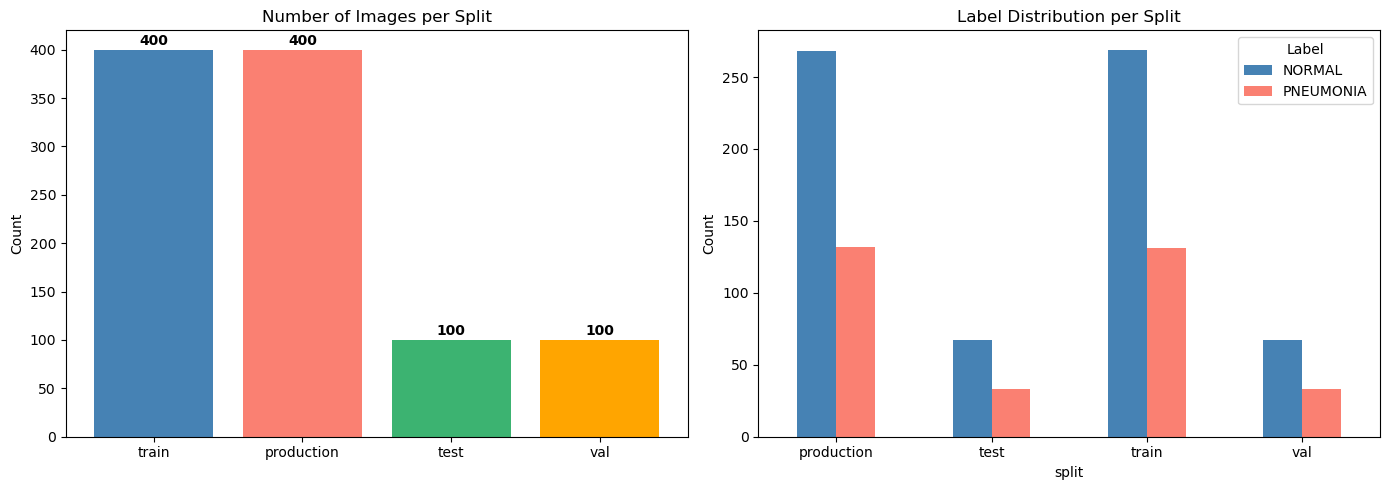

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Split sizes
split_sizes = df_split["split"].value_counts()
axes[0].bar(split_sizes.index, split_sizes.values, color=["steelblue", "salmon", "mediumseagreen", "orange"])
axes[0].set_title("Number of Images per Split")
axes[0].set_ylabel("Count")
for i, v in enumerate(split_sizes.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")

# Label distribution per split
split_label = df_split.groupby(["split", "label"]).size().unstack(fill_value=0)
split_label.plot(kind="bar", ax=axes[1], color=["steelblue", "salmon"])
axes[1].set_title("Label Distribution per Split")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Label")

plt.tight_layout()
plt.show()

### Step 8: Benchmark Model in SageMaker
#### Simple baseline model using pixel_mean and pixel_std only

In [56]:
import os
import json
import boto3
import sagemaker
import pandas as pd
import numpy as np

from sagemaker.sklearn.estimator import SKLearn

sess = sagemaker.Session()
role = sagemaker.get_execution_role()
region = boto3.Session().region_name
s3 = boto3.client("s3")

print(f"Region: {region}")
print(f"Role: {role}")
print(f"Default bucket: {default_bucket}")
print(f"Data bucket: {bucket}")

Region: us-east-1
Role: arn:aws:iam::929599411455:role/LabRole
Default bucket: sagemaker-us-east-1-929599411455
Data bucket: pneumonia-data-set-group-4


In [57]:
# Prepare simple benchmark training data

benchmark_features = ["pixel_mean", "pixel_std"]
target_col = "label_int"

required_cols = benchmark_features + [target_col, "split"]

missing_cols = [col for col in required_cols if col not in df_split.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

df_benchmark = df_split[required_cols].copy()

print(df_benchmark.head())
print(df_benchmark["split"].value_counts())

   pixel_mean  pixel_std  label_int  split
0    110.2782    59.7904          0  train
1    155.0163    64.5422          1  train
2    117.4796    70.1062          0  train
3    108.4307    74.2262          0  train
4    151.0070    66.6774          0  train
split
train         400
production    400
test          100
val           100
Name: count, dtype: int64


In [58]:
# Create train, validation, and test CSV files
# SageMaker SKLearn expects the target column to be included in the CSV

benchmark_dir = "benchmark-data"
os.makedirs(benchmark_dir, exist_ok=True)

train_df = df_benchmark[df_benchmark["split"] == "train"].drop(columns=["split"])
val_df = df_benchmark[df_benchmark["split"] == "val"].drop(columns=["split"])
test_df = df_benchmark[df_benchmark["split"] == "test"].drop(columns=["split"])

train_path = f"{benchmark_dir}/train.csv"
val_path = f"{benchmark_dir}/validation.csv"
test_path = f"{benchmark_dir}/test.csv"

train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)
test_df.to_csv(test_path, index=False)

print(f"Train shape: {train_df.shape}")
print(f"Validation shape: {val_df.shape}")
print(f"Test shape: {test_df.shape}")

Train shape: (400, 3)
Validation shape: (100, 3)
Test shape: (100, 3)


In [59]:
# Upload benchmark data to S3

benchmark_prefix = "pneumonia-project/benchmark-model"

train_s3_uri = sess.upload_data(
    path=train_path,
    bucket=default_bucket,
    key_prefix=f"{benchmark_prefix}/data/train"
)

val_s3_uri = sess.upload_data(
    path=val_path,
    bucket=default_bucket,
    key_prefix=f"{benchmark_prefix}/data/validation"
)

test_s3_uri = sess.upload_data(
    path=test_path,
    bucket=default_bucket,
    key_prefix=f"{benchmark_prefix}/data/test"
)

print("Training data:", train_s3_uri)
print("Validation data:", val_s3_uri)
print("Test data:", test_s3_uri)

Training data: s3://sagemaker-us-east-1-929599411455/pneumonia-project/benchmark-model/data/train/train.csv
Validation data: s3://sagemaker-us-east-1-929599411455/pneumonia-project/benchmark-model/data/validation/validation.csv
Test data: s3://sagemaker-us-east-1-929599411455/pneumonia-project/benchmark-model/data/test/test.csv


In [60]:
# Create SageMaker training script for benchmark model

script_dir = "benchmark_script"
os.makedirs(script_dir, exist_ok=True)

train_script = f"{script_dir}/train_benchmark.py"

script_content = '''
import argparse
import os
import json
import joblib
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


def calculate_specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0.0


if __name__ == "__main__":
    parser = argparse.ArgumentParser()

    parser.add_argument("--max-iter", type=int, default=1000)
    parser.add_argument("--random-state", type=int, default=42)

    args = parser.parse_args()

    train_dir = os.environ["SM_CHANNEL_TRAIN"]
    val_dir = os.environ["SM_CHANNEL_VALIDATION"]
    test_dir = os.environ["SM_CHANNEL_TEST"]
    model_dir = os.environ["SM_MODEL_DIR"]

    train_file = os.path.join(train_dir, "train.csv")
    val_file = os.path.join(val_dir, "validation.csv")
    test_file = os.path.join(test_dir, "test.csv")

    train_df = pd.read_csv(train_file)
    val_df = pd.read_csv(val_file)
    test_df = pd.read_csv(test_file)

    feature_cols = ["pixel_mean", "pixel_std"]
    target_col = "label_int"

    X_train = train_df[feature_cols]
    y_train = train_df[target_col]

    X_val = val_df[feature_cols]
    y_val = val_df[target_col]

    X_test = test_df[feature_cols]
    y_test = test_df[target_col]

    model = LogisticRegression(
        max_iter=args.max_iter,
        random_state=args.random_state,
        class_weight="balanced"
    )

    model.fit(X_train, y_train)

    val_preds = model.predict(X_val)
    test_preds = model.predict(X_test)

    val_metrics = {
        "validation_accuracy": accuracy_score(y_val, val_preds),
        "validation_precision": precision_score(y_val, val_preds, zero_division=0),
        "validation_recall": recall_score(y_val, val_preds, zero_division=0),
        "validation_f1": f1_score(y_val, val_preds, zero_division=0),
        "validation_specificity": calculate_specificity(y_val, val_preds)
    }

    test_metrics = {
        "test_accuracy": accuracy_score(y_test, test_preds),
        "test_precision": precision_score(y_test, test_preds, zero_division=0),
        "test_recall": recall_score(y_test, test_preds, zero_division=0),
        "test_f1": f1_score(y_test, test_preds, zero_division=0),
        "test_specificity": calculate_specificity(y_test, test_preds)
    }

    metrics = {**val_metrics, **test_metrics}

    print("Benchmark Model Metrics")
    print(json.dumps(metrics, indent=4))

    for key, value in metrics.items():
        print(f"{key}: {value}")

    joblib.dump(model, os.path.join(model_dir, "model.joblib"))
'''

with open(train_script, "w") as f:
    f.write(script_content)

print(f"Created training script: {train_script}")

Created training script: benchmark_script/train_benchmark.py


In [61]:
# Create SageMaker SKLearn Estimator

benchmark_output_path = f"s3://{default_bucket}/{benchmark_prefix}/output"

benchmark_estimator = SKLearn(
    entry_point="train_benchmark.py",
    source_dir=script_dir,
    role=role,
    instance_type="ml.m5.large",
    instance_count=1,
    framework_version="1.2-1",
    py_version="py3",
    output_path=benchmark_output_path,
    hyperparameters={
        "max-iter": 1000,
        "random-state": 42
    },
    metric_definitions=[
        {"Name": "validation_accuracy", "Regex": "validation_accuracy: ([0-9\\.]+)"},
        {"Name": "validation_precision", "Regex": "validation_precision: ([0-9\\.]+)"},
        {"Name": "validation_recall", "Regex": "validation_recall: ([0-9\\.]+)"},
        {"Name": "validation_f1", "Regex": "validation_f1: ([0-9\\.]+)"},
        {"Name": "validation_specificity", "Regex": "validation_specificity: ([0-9\\.]+)"},
        {"Name": "test_accuracy", "Regex": "test_accuracy: ([0-9\\.]+)"},
        {"Name": "test_precision", "Regex": "test_precision: ([0-9\\.]+)"},
        {"Name": "test_recall", "Regex": "test_recall: ([0-9\\.]+)"},
        {"Name": "test_f1", "Regex": "test_f1: ([0-9\\.]+)"},
        {"Name": "test_specificity", "Regex": "test_specificity: ([0-9\\.]+)"}
    ]
)

print("Benchmark estimator ready.")
print("Output path:", benchmark_output_path)

Benchmark estimator ready.
Output path: s3://sagemaker-us-east-1-929599411455/pneumonia-project/benchmark-model/output


In [62]:
# Run SageMaker training job

benchmark_estimator.fit(
    {
        "train": train_s3_uri,
        "validation": val_s3_uri,
        "test": test_s3_uri
    }
)

INFO:sagemaker:Creating training-job with name: sagemaker-scikit-learn-2026-06-02-03-39-41-998


2026-06-02 03:39:44 Starting - Starting the training job.

.

.


2026-06-02 03:39:58 Starting - Preparing the instances for training.

...

.


2026-06-02 03:42:14 Training - Training image download completed. Training in progress..

/miniconda3/lib/python3.9/site-packages/sagemaker_containers/_server.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
2026-06-02 03:42:18,438 sagemaker-containers INFO     Imported framework sagemaker_sklearn_container.training
2026-06-02 03:42:18,446 sagemaker-training-toolkit INFO     No GPUs detected (normal if no gpus installed)
2026-06-02 03:42:18,450 sagemaker-training-toolkit INFO     No Neurons detected (normal if no neurons installed)
2026-06-02 03:42:18,468 sagemaker_sklearn_container.training INFO     Invoking user training script.
2026-06-02 03:42:18,809 sagemaker-training-toolkit INFO     No GPUs detected (normal if no gpus installed)
2026-06-02 03:42:18,812 sagemaker-training-toolkit INFO     No Neurons detected (normal if no neurons installed)
2026-06-


2026-06-02 03:42:38 Uploading - Uploading generated training model
2026-06-02 03:42:38 Completed - Training job completed


Training seconds: 135
Billable seconds: 135


In [63]:
# Show completed training job info

training_job_name = benchmark_estimator.latest_training_job.name

print("Benchmark training job completed.")
print("Training job name:", training_job_name)
print("Model artifact location:")
print(benchmark_estimator.model_data)

Benchmark training job completed.
Training job name: sagemaker-scikit-learn-2026-06-02-03-39-41-998
Model artifact location:
s3://sagemaker-us-east-1-929599411455/pneumonia-project/benchmark-model/output/sagemaker-scikit-learn-2026-06-02-03-39-41-998/output/model.tar.gz


### Step 9: First Real CNN Model in SageMaker